# Playground for LLMs

Llama 3.2 1B Instruct model

In [ ]:
from src.llm import LLM

model = LLM(model_id="meta-llama/Llama-3.2-1B-Instruct")

prompt = ["What is the capital of Italy?"]
response = model.generate_batch(prompt)

print(response[0][0])

Llama 3.2 70B Chat model with 8-bit quantization

In [ ]:
from src.llm import LLM

model = LLM(model_id="meta-llama/Llama-2-70b-chat-hf")

prompt = ["What is the capital of Israel?"]
response = model.generate_batch(prompt)

print(response[0][0])

Model: meta-llama/Llama-3.2-3B-Instruct
Dataset: amsterdam
Label: pick


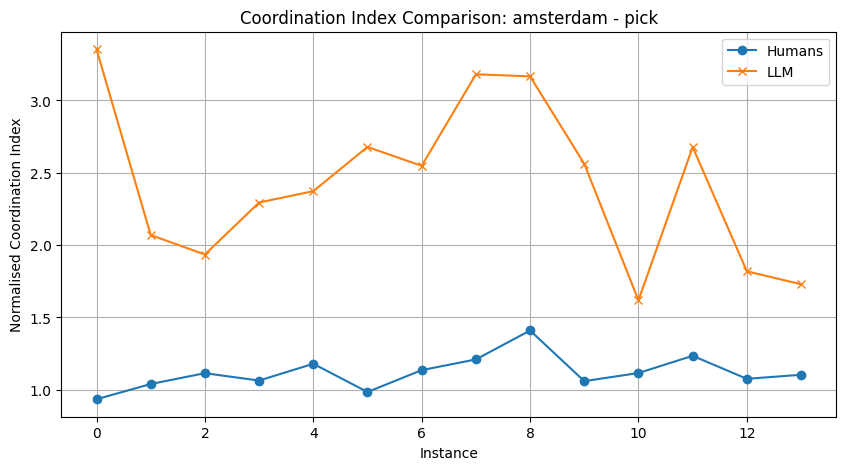

Label: guess


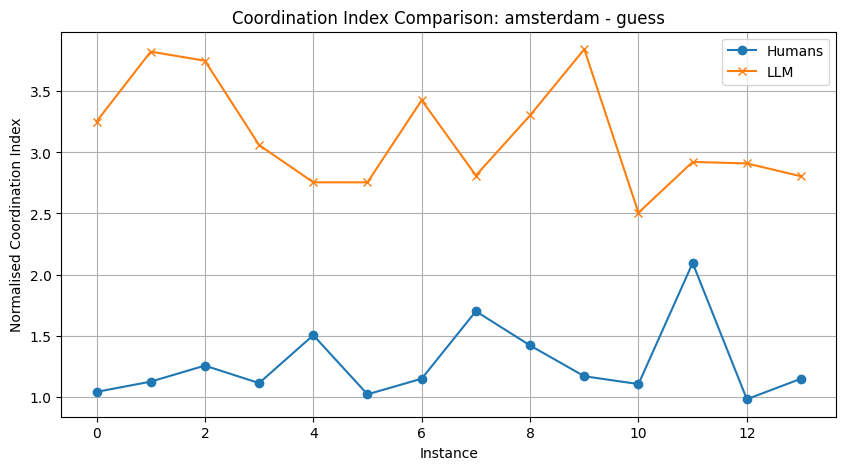

Label: coordinate


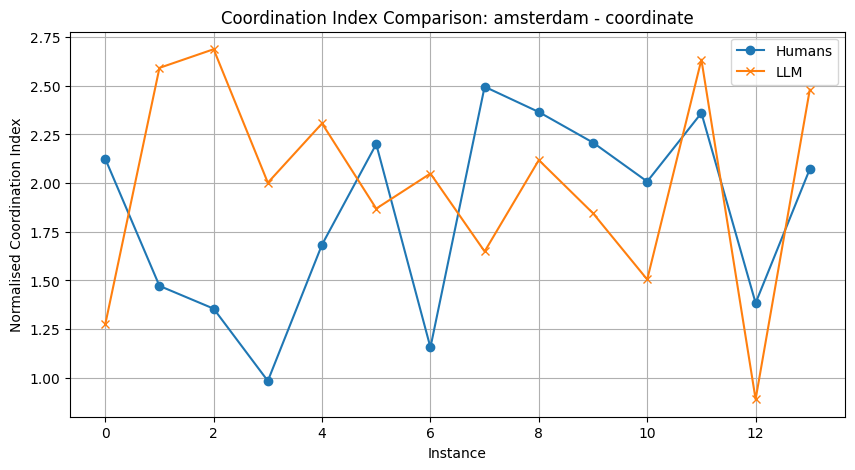

Dataset: nottingham
Label: pick


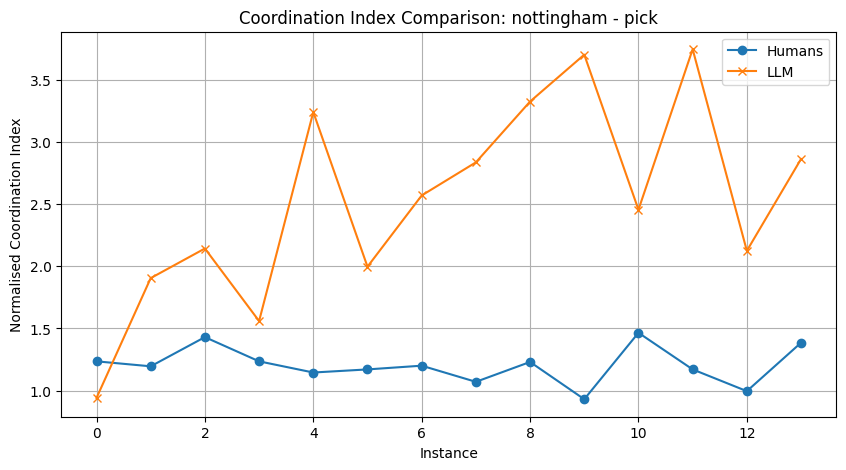

Label: guess


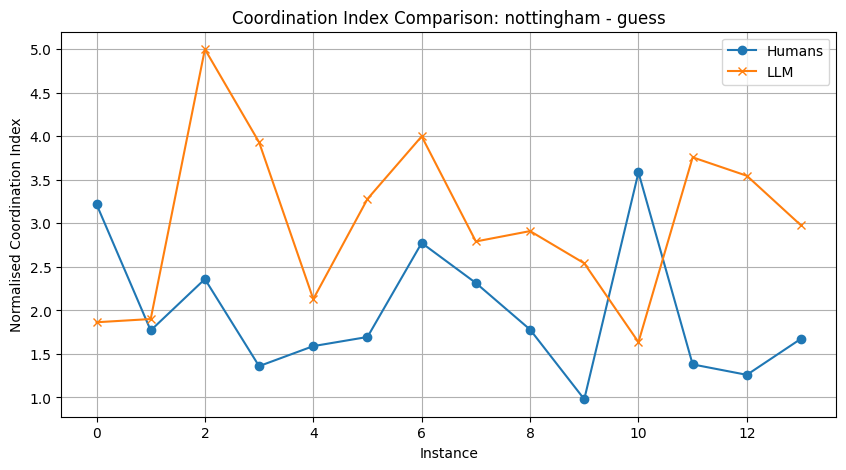

Label: coordinate


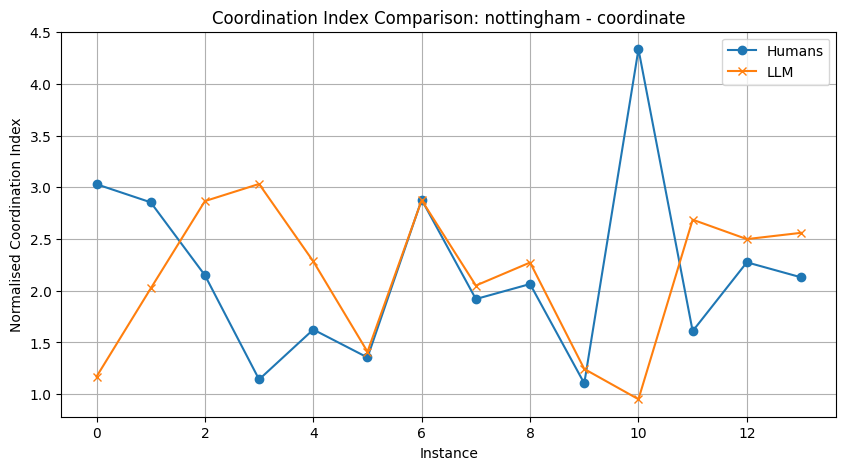

In [49]:
import json
import matplotlib.pyplot as plt

model_name = "meta-llama/Llama-3.2-3B-Instruct"
dataset_names = ["amsterdam", "nottingham"]
labels = ["pick", "guess", "coordinate"]

print(f"Model: {model_name}")
for d_name in dataset_names:
    
    print(f"Dataset: {d_name}")
    for l in labels:
        
        print(f"Label: {l}")
        with open(f"./results/{model_name}/{d_name}_problem-{l}.jsonl", "r") as f:
            data_llm = json.load(f)
            
        with open(f"./data/Bardsley-humans/{d_name}.jsonl", "r") as f:
            data_humans = json.load(f)
        
        current_data_humans = []
        for d in data_humans:
            if d["task"] == l:
                current_data_humans.append(d["normalised_coordination_index"])
                
        current_data_llm = []
        for i in range(0, len(data_llm), 3):
            current_data_llm.append(sum([d["normalised_coordination_index"] for d in data_llm[i:i+3]])/3)
        
        # Plot the results with matplotlib
        plt.figure(figsize=(10, 5))
        plt.plot(current_data_humans, label="Humans", marker='o')
        plt.plot(current_data_llm, label="LLM", marker='x')
        plt.title(f"Coordination Index Comparison: {d_name} - {l}")
        plt.xlabel("Instance")
        plt.ylabel("Normalised Coordination Index")
        plt.legend()
        plt.grid()
        plt.show()

10.061616161616161

In [41]:
data_llm

[{'idx': 'TA1',
  'variation-idx': '0',
  'prompt': 'In this task, you have to choose one of the following options. This is the list of options and their score: grijs: 10, indigo: 10, karmozijn: 10, magenta: 10, turkoois: 10. You will earn the number of points shown on the option you choose. Your earnings are determined by your decisions alone.',
  'responses': {'grijs10': 45, 'grijs': 55},
  'coordination_index': 0.5,
  'normalised_coordination_index': 2.5},
 {'idx': 'TA1',
  'variation-idx': '1',
  'prompt': 'In this task, you have to choose one of the following options. This is the list of options and their score: karmozijn: 10, grijs: 10, magenta: 10, indigo: 10, turkoois: 10. You will earn the number of points shown on the option you choose. Your earnings are determined by your decisions alone.',
  'responses': {'karmozijn': 85, 'magenta10': 3, 'magenta': 12},
  'coordination_index': 0.7351515151515151,
  'normalised_coordination_index': 3.675757575757576},
 {'idx': 'TA1',
  'vari